# Thesis Plots — Cross-Model Comparison

**Plot A** — Model × Strategy grouped bar (does fine-tuning generalize across architectures?)  
**Plot B** — QUR vs FRR scatter (refusal–collapse tradeoff per model × dataset)

In [ ]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

BASE = "/home/amartinelli/VRD-UQA/artifacts/presentations"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Models ──────────────────────────────────────────────────
MODELS = [
    {"key": "qwen_all_val_300",     "label": "Qwen2.5-VL",  "color": "#4C72B0", "marker": "o"},
    {"key": "internvl_all_val_300", "label": "InternVL3.5", "color": "#DD8452", "marker": "s"},
    {"key": "phi4_all_val_300",     "label": "Phi-4",        "color": "#55A868", "marker": "^"},
    {"key": "gemma4_all_val_300",   "label": "Gemma4",       "color": "#C44E52", "marker": "D"},
]
MODEL_BY_KEY = {m["key"]: m for m in MODELS}

DATASETS = ["DUDE", "MPDocVQA", "SlideVQA", "BDocs"]
DATASET_LABELS = {
    "DUDE": "DUDE", "MPDocVQA": "MPDocVQA",
    "SlideVQA": "SlideVQA", "BDocs": "BoundingDocs",
}
DATASET_MARKERS = {"DUDE": "o", "MPDocVQA": "s", "SlideVQA": "^", "BDocs": "D"}

# ── Strategy normalisation ───────────────────────────────────
# Config slugs differ between models (e.g. qwen uses 'zeroshot', others 'zeroshot_ocr').
# Map everything to a canonical strategy key.
def strategy_key(slug):
    if slug.startswith("zeroshot"):  return "zeroshot"
    if slug.startswith("fewshot"):   return "fewshot"
    if slug.startswith("finetuned"): return "finetuned"
    return slug

STRATEGIES = ["zeroshot", "fewshot", "finetuned"]
STRATEGY_LABELS  = {"zeroshot": "Zero-Shot", "fewshot": "Few-Shot", "finetuned": "Fine-Tuned (LoRA)"}
STRATEGY_COLORS  = {"zeroshot": "#7B2FBE",   "fewshot": "#DC3545",  "finetuned": "#20B2AA"}
STRATEGY_HATCHES = {"zeroshot": "",           "fewshot": "",          "finetuned": ""}

# ── Helpers ──────────────────────────────────────────────────
def load_metric(model_key, dataset, config_slug, filename):
    path = os.path.join(BASE, model_key, dataset, config_slug, "metrics", filename)
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path, index_col=0)
    s.columns = ["value"]
    return s["value"]

def discover_config_slug(model_key, dataset, strategy):
    """Return the config slug for a given model/dataset/strategy, or None."""
    for man in glob.glob(os.path.join(BASE, model_key, dataset, "*", "manifest.json")):
        slug = os.path.basename(os.path.dirname(man))
        if strategy_key(slug) == strategy:
            return slug
    return None

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.linestyle": "--", "grid.alpha": 0.5,
})

print("Setup complete.")
print("Models:", [m['label'] for m in MODELS])
print("Datasets:", DATASETS)


## Load QUR and FRR data

In [2]:
records = []

for m in MODELS:
    for dataset in DATASETS:
        for strat in STRATEGIES:
            slug = discover_config_slug(m["key"], dataset, strat)
            if slug is None:
                continue
            qur_s = load_metric(m["key"], dataset, slug, "QUR.csv")
            frr_s = load_metric(m["key"], dataset, slug, "FRR.csv")  # only finetuned
            if qur_s is None:
                continue
            records.append({
                "model":    m["key"],
                "model_label": m["label"],
                "dataset":  dataset,
                "strategy": strat,
                "QUR":      qur_s.get("QUR",    np.nan),
                "QUR_C1":   qur_s.get("QUR_C1", np.nan),
                "QUR_C2":   qur_s.get("QUR_C2", np.nan),
                "FRR":      frr_s.get("FRR",    np.nan) if frr_s is not None else np.nan,
            })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records")
df.pivot_table(index=["model_label", "strategy"], columns="dataset", values="QUR").round(3)

Loaded 47 records


dataset                BDocs   DUDE  MPDocVQA  SlideVQA
model_label strategy                                   
Gemma4      fewshot    0.643  0.767     0.627     0.520
            finetuned  0.853  0.853     0.800     0.590
            zeroshot   0.570  0.620     0.567     0.467
InternVL3.5 fewshot    0.657  0.680     0.513     0.450
            finetuned  0.727  0.703     0.617     0.410
            zeroshot   0.617  0.660     0.630     0.433
Phi-4       fewshot      NaN  0.597     0.313     0.293
            finetuned  0.787  0.720     0.680     0.400
            zeroshot   0.453  0.543     0.397     0.160
Qwen2.5-VL  fewshot    0.663  0.620     0.513     0.473
            finetuned  0.837  0.827     0.787     0.643
            zeroshot   0.710  0.630     0.567     0.580

## Plot A — Model Comparison: QUR by Strategy

Does fine-tuning improve QUR universally across architectures, or only for Qwen?  
Each panel shows one dataset; bars are grouped by model, coloured by strategy.

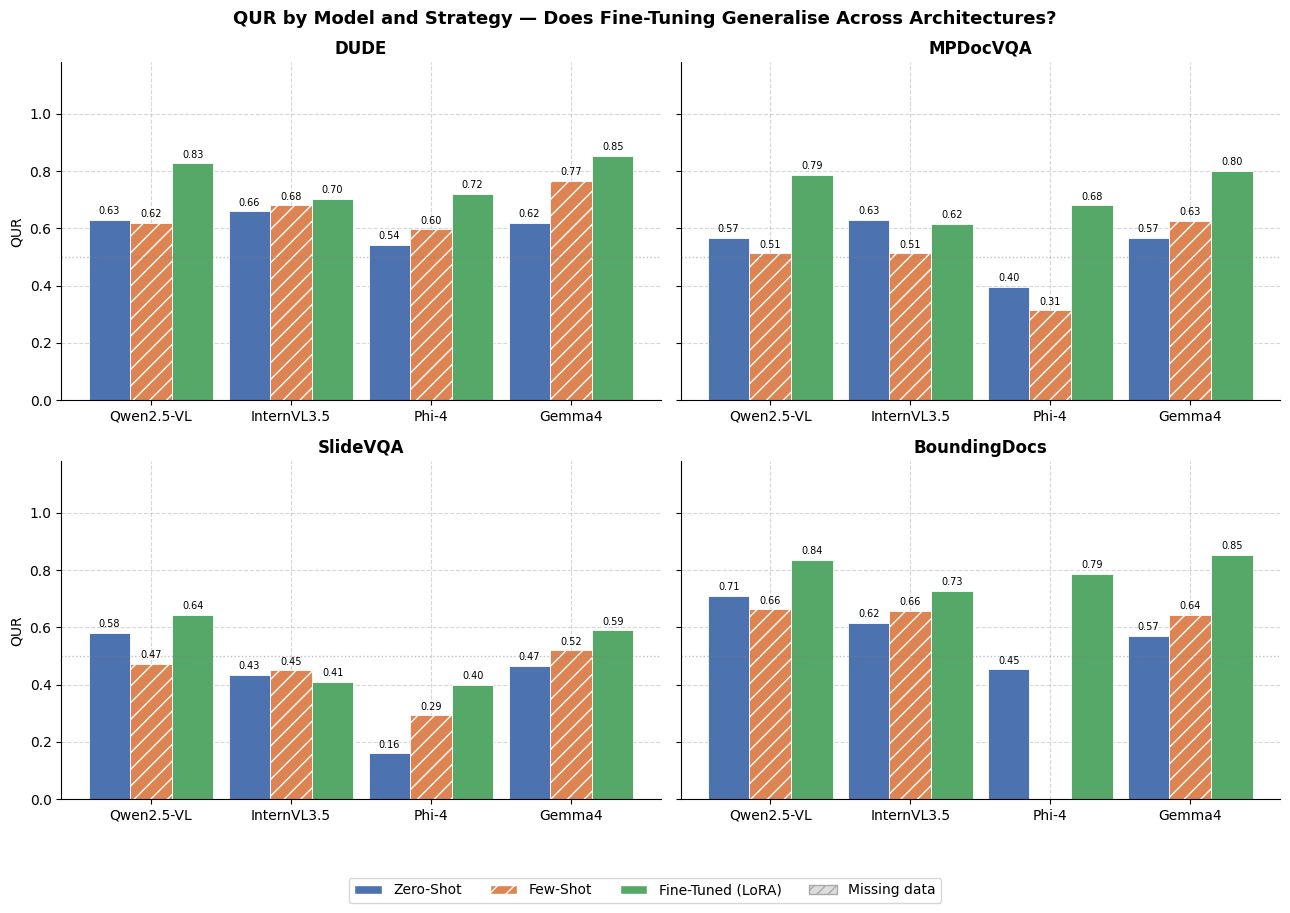

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
axes = axes.flatten()

n_models    = len(MODELS)
n_strategies = len(STRATEGIES)
bar_w = 0.22
group_gap = 0.08           # extra gap between model groups
group_w = n_strategies * bar_w + group_gap
x_groups = np.arange(n_models) * group_w

for ax_idx, dataset in enumerate(DATASETS):
    ax = axes[ax_idx]
    sub = df[df.dataset == dataset]

    for s_idx, strat in enumerate(STRATEGIES):
        s_sub = sub[sub.strategy == strat]
        vals = []
        for m in MODELS:
            row = s_sub[s_sub.model == m["key"]]
            vals.append(row["QUR"].values[0] if not row.empty else np.nan)

        x_pos = x_groups + s_idx * bar_w
        plot_vals = [v if not np.isnan(v) else 0 for v in vals]
        bars = ax.bar(
            x_pos, plot_vals, width=bar_w,
            color=STRATEGY_COLORS[strat],
            hatch=STRATEGY_HATCHES[strat],
            edgecolor="white", linewidth=0.6,
            label=STRATEGY_LABELS[strat] if ax_idx == 0 else None,
        )
        for bar, val in zip(bars, vals):
            if np.isnan(val):
                bar.set_facecolor("#dddddd")
                bar.set_edgecolor("#aaaaaa")
                bar.set_hatch("///")
            else:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.013,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7)

    # Model labels centred on each group
    tick_positions = x_groups + (n_strategies - 1) * bar_w / 2
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([m["label"] for m in MODELS], fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_title(DATASET_LABELS[dataset], fontsize=12, fontweight="bold")
    if ax_idx % 2 == 0:
        ax.set_ylabel("QUR", fontsize=10)
    ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.5)

strategy_handles = [
    mpatches.Patch(facecolor=STRATEGY_COLORS[s], hatch=STRATEGY_HATCHES[s],
                   edgecolor="white", label=STRATEGY_LABELS[s])
    for s in STRATEGIES
]
na_handle = mpatches.Patch(facecolor="#dddddd", edgecolor="#aaaaaa",
                            hatch="///", label="Missing data")
fig.legend(handles=strategy_handles + [na_handle], loc="lower center",
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    "QUR by Model and Strategy — Does Fine-Tuning Generalise Across Architectures?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plotA_model_comparison_per_dataset.pdf"), bbox_inches="tight")
plt.show()

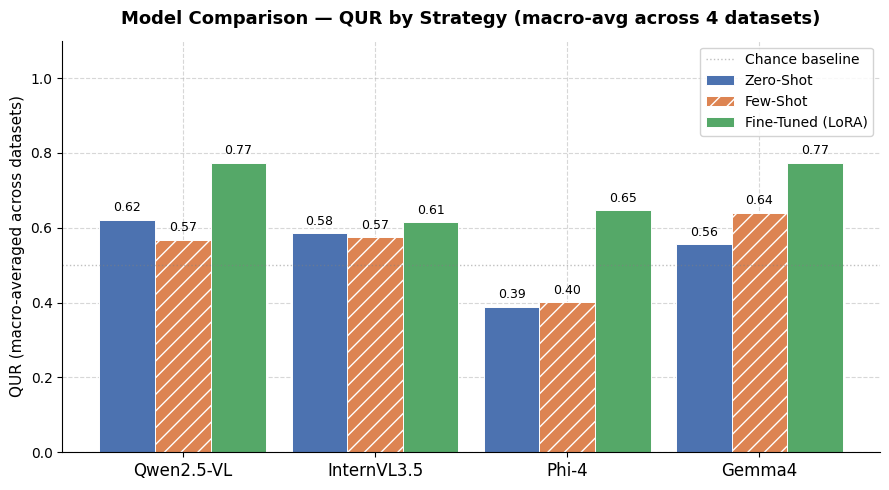

In [4]:
# Macro-averaged version (single chart) — cleaner headline figure.
macro = (
    df.groupby(["model", "model_label", "strategy"])["QUR"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

bar_w = 0.22
group_gap = 0.1
group_w = n_strategies * bar_w + group_gap
x_groups = np.arange(n_models) * group_w

for s_idx, strat in enumerate(STRATEGIES):
    s_sub = macro[macro.strategy == strat]
    vals = []
    for m in MODELS:
        row = s_sub[s_sub.model == m["key"]]
        vals.append(row["QUR"].values[0] if not row.empty else np.nan)

    x_pos = x_groups + s_idx * bar_w
    plot_vals = [v if not np.isnan(v) else 0 for v in vals]
    bars = ax.bar(
        x_pos, plot_vals, width=bar_w,
        color=STRATEGY_COLORS[strat],
        hatch=STRATEGY_HATCHES[strat],
        edgecolor="white", linewidth=0.7,
        label=STRATEGY_LABELS[strat],
    )
    for bar, val in zip(bars, vals):
        if np.isnan(val):
            bar.set_facecolor("#dddddd")
            bar.set_edgecolor("#aaaaaa")
            bar.set_hatch("///")
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)

tick_positions = x_groups + (n_strategies - 1) * bar_w / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels([m["label"] for m in MODELS], fontsize=12)
ax.set_ylabel("QUR (macro-averaged across datasets)", fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.5, label="Chance baseline")
ax.set_title(
    "Model Comparison — QUR by Strategy (macro-avg across 4 datasets)",
    fontsize=13, fontweight="bold", pad=12
)
ax.legend(fontsize=10, framealpha=0.85)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plotA_model_comparison_macro.pdf"), bbox_inches="tight")
plt.show()

## Plot B — QUR vs FRR: Refusal–Collapse Tradeoff

Each point = one (model, dataset) pair under the **Fine-Tuned (LoRA)** configuration.  
FRR is only computed for fine-tuned configs (requires answerable-question results).  
**Good models sit top-left** (high QUR = correctly refuses unanswerable, low FRR = rarely refuses answerable).  
Points on the diagonal suggest the model refuses at a fixed rate regardless of question type (refusal collapse).

In [ ]:
ft_df = df[(df.strategy == "finetuned") & df["FRR"].notna() & df["QUR"].notna()].copy()

# ── Compute per-model macro-averages ─────────────────────────────────────────
model_means = ft_df.groupby("model")[["FRR", "QUR"]].mean()

# Fixed text-anchor positions (axes-fraction coords) for avg-star labels.
# Chosen so each label sits in a clear, uncrowded region with an arrow to the star.
STAR_ANCHORS = {
    "qwen_all_val_300":     (0.98, 0.95),   # top-right
    "gemma4_all_val_300":   (0.02, 0.97),   # top-left
    "phi4_all_val_300":     (0.02, 0.42),   # middle-left
    "internvl_all_val_300": (0.98, 0.30),   # bottom-right
}
STAR_HA = {
    "qwen_all_val_300": "right", "gemma4_all_val_300": "left",
    "phi4_all_val_300": "left",  "internvl_all_val_300": "right",
}

fig, ax = plt.subplots(figsize=(8, 7))

# ── Individual scatter points (no text labels — shape + color carry all info) ─
for m in MODELS:
    m_sub = ft_df[ft_df.model == m["key"]]
    for _, row in m_sub.iterrows():
        ax.scatter(
            row["FRR"], row["QUR"],
            color=m["color"], marker=DATASET_MARKERS[row["dataset"]],
            s=120, zorder=4, edgecolors="white", linewidths=1.0, alpha=0.88,
        )

# ── Macro-average stars with explicit arrow annotations ──────────────────────
for m in MODELS:
    if m["key"] not in model_means.index:
        continue
    mx = model_means.loc[m["key"], "FRR"]
    my = model_means.loc[m["key"], "QUR"]
    ax.scatter(mx, my, color=m["color"], marker="*",
               s=420, zorder=5, edgecolors="black", linewidths=0.9)

    ax.annotate(
        m["label"],
        xy=(mx, my),                            # arrow tip: the star
        xycoords="data",
        xytext=STAR_ANCHORS[m["key"]],          # label anchor: fixed axes fraction
        textcoords="axes fraction",
        ha=STAR_HA[m["key"]], va="center",
        fontsize=9.5, fontweight="bold", color=m["color"],
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=m["color"], linewidth=1.2, alpha=0.92),
        arrowprops=dict(arrowstyle="-|>", color=m["color"],
                        lw=1.4, connectionstyle="arc3,rad=0.15"),
    )

# ── Reference lines ──────────────────────────────────────────────────────────
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, alpha=0.4, zorder=1)
ax.scatter([0], [1], marker="*", s=450, color="gold",
           edgecolors="black", linewidths=0.9, zorder=6)
ax.annotate("Ideal", xy=(0, 1), xytext=(14, -16),
            textcoords="offset points", fontsize=9, color="#888800", fontweight="bold")

# ── Legend ────────────────────────────────────────────────────────────────────
model_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=m["color"],
           markersize=10, markeredgecolor="white", label=m["label"])
    for m in MODELS
]
dataset_handles = [
    Line2D([0], [0], marker=DATASET_MARKERS[d], color="grey",
           markersize=9, markeredgecolor="white", label=DATASET_LABELS[d])
    for d in DATASETS
]
star_handle = Line2D([0], [0], marker="*", color="w", markerfacecolor="grey",
                     markersize=13, markeredgecolor="black", label="Model avg (★)")
diag_handle = Line2D([0], [0], color="grey", linestyle="--",
                     linewidth=1, alpha=0.6, label="Collapse diagonal")

ax.legend(
    handles=model_handles + [star_handle] + dataset_handles + [diag_handle],
    fontsize=8.5, loc="lower right", framealpha=0.90, ncol=2,
)

ax.set_xlim(-0.04, 0.60)
ax.set_ylim(0.35, 1.08)
ax.set_xlabel("False Refusal Rate (FRR)  — incorrectly refuses answerable  ↓ better",
              fontsize=10)
ax.set_ylabel("Question Unanswerability Rate (QUR)  — correctly refuses unanswerable  ↑ better",
              fontsize=10)
ax.set_title(
    "Refusal–Collapse Tradeoff — Fine-Tuned (LoRA) Models\n"
    "(top-left = discriminates well;  diagonal = collapses to fixed refusal rate)",
    fontsize=12, fontweight="bold", pad=12,
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plotB_qur_vs_frr_scatter.pdf"), bbox_inches="tight")
plt.show()
